# Notebook 2 - Melatih Autoencoder (Dense / Denoising / VAE) untuk Deteksi Anomali Greenhouse
---
Adaptasi `anomaly-detection-training-autoencoder.ipynb` (EPTA2026-EdgeAI). Notebook ini **tidak lagi membersihkan data sendiri**: data yang dipakai adalah
**dataset bersih hasil Notebook 1 (feature analysis)**, dimuat dari folder `datasets/clean/`. Daftar fitur, rentang fisik, kebijakan imputasi, ukuran window,
dan pembagian blok semuanya dibaca dari `feature_analysis_config.json` supaya Notebook 1, 2, dan 3 tidak bisa tidak sinkron.

| | Proyek referensi (kipas) | Proyek ini (greenhouse) |
|---|---|---|
| Input | vektor fitur statistik (MAD 3 sumbu) | **window mentah** `(24 jam, n_fitur)` yang di-*flatten* |
| Arsitektur | Dense autoencoder | **Dense (fully-connected) Autoencoder**; varian: Denoising (`dae`) atau Variational (`vae`) - tanpa CNN1D / LSTM |
| Data normal | folder kondisi normal | seluruh **2024 bersih** (split per blok 7 hari) |
| Anomali | rekaman kipas rusak | **anomali sintetis** pada window **2025 bersih** |

Prinsip *unsupervised*: model hanya melihat data **normal** dan dilatih merekonstruksi input (`Y = X`).
Window anomali direkonstruksi buruk → **MSE tinggi** → dilabeli anomali bila MSE > *threshold*.

**File yang harus ada di Google Drive sebelum menjalankan notebook ini** (dibuat oleh Notebook 1, bagian 5.4 dan akhir notebook):
```
greenhouse-anomaly-edgeai/
  datasets/
    clean/
      dindigul_greenhouse_indoor_2024_clean.csv
      dindigul_greenhouse_indoor_2025_clean.csv
      feature_analysis_config.json
```


### 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Import library

In [2]:
import os, json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3})
SEED = 42
keras.utils.set_random_seed(SEED)
print('TensorFlow', tf.__version__, '| Keras', keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


### 3. Pengaturan
- `model_type`: `'ae'` (default, **Autoencoder Dense** biasa), `'dae'` (**Denoising** Dense Autoencoder), atau `'vae'` (**Variational** Autoencoder berbasis Dense). Semuanya hanya memakai layer Dense/Flatten/Reshape sehingga ramah TFLite int8.
- Split **per blok** (`block_hours` dibaca dari Notebook 1, 168 = 7 hari) agar window train/val/test tidak saling tumpang-tindih (anti-leakage).
- Karena memakai Dense (bukan Conv + pooling), `window_length_hours` bebas (tidak perlu kelipatan 4); ukuran input = `window_length_hours × n_fitur`.

In [3]:
# ------------------------------------------------------------------
# PENGATURAN PATH (semua merujuk ke folder di Google Drive)
# ------------------------------------------------------------------
BASE_PATH    = '/content/drive/MyDrive/greenhouse-anomaly-edgeai'
dataset_path = f'{BASE_PATH}/datasets'
models_path  = f'{BASE_PATH}/models'

CLEAN_DIR    = f'{dataset_path}/clean'          # keluaran Notebook 1 (data bersih + config)
clean_2024   = 'dindigul_greenhouse_indoor_2024_clean.csv'
clean_2025   = 'dindigul_greenhouse_indoor_2025_clean.csv'
fa_config_file = join(CLEAN_DIR, 'feature_analysis_config.json')

for f in (clean_2024, clean_2025, 'feature_analysis_config.json'):
    assert os.path.exists(join(CLEAN_DIR, f)), f'{f} tidak ditemukan di {CLEAN_DIR}. Jalankan Notebook 1 sampai selesai dulu.'
fa_cfg = json.load(open(fa_config_file))

# Parameter data dibaca dari Notebook 1 (ubah di Notebook 1, bukan di sini)
FEATURES            = fa_cfg['features']
window_length_hours = fa_cfg['window_length_hours']   # boleh diganti manual untuk eksperimen (mis. 12 / 48)
hop_hours           = fa_cfg['hop_hours']
block_hours         = fa_cfg['block_hours']
val_ratio, test_ratio = fa_cfg['val_ratio'], fa_cfg['test_ratio']
assert fa_cfg['seed'] == SEED, 'SEED notebook ini harus sama dengan Notebook 1 agar split blok identik'

# --- Pengaturan model & training ---
model_type  = 'ae'           # 'ae' | 'dae' | 'vae'   (semua Dense autoencoder)
hidden_units = (128, 64)     # lebar layer Dense encoder (decoder simetris)
bottleneck_dim = 32          # dimensi bottleneck 'ae' / 'dae'
noise_std   = 0.15           # std noise Gaussian (hanya dipakai 'dae', pada ruang data ter-scale)
latent_dim  = 16             # dimensi laten (hanya 'vae')
vae_beta    = 1e-3           # bobot KL-divergence (hanya 'vae')
epochs      = 60
batch_size  = 64
n_anomaly_eval = 1500        # jumlah window anomali sintetis untuk evaluasi

keras_model_name  = f'greenhouse_ae_model_{model_type}'    # -> .h5
scaler_name       = 'greenhouse_scaler'                    # -> .joblib
sample_file_name  = 'greenhouse_normal_anomaly_samples'    # -> .npz
config_name       = 'greenhouse_config'                    # -> .json

assert model_type in ('ae', 'dae', 'vae'), "model_type harus 'ae', 'dae', atau 'vae'"

### 4. Muat data bersih dari Notebook 1 + fungsi bantu
Pembersihan (duplikat, jam hilang, nilai mustahil, drop kolom, imputasi, `vpd` dihitung ulang) sudah dikerjakan dan dibuktikan di Notebook 1, lalu disimpan ke `datasets/clean/`.
Di sini data cukup dimuat dan divalidasi ulang (deret jam-an kontinu, tanpa NaN, dalam rentang fisik, biner hanya 0/1).

In [4]:
def load_clean(year):
    # Muat data bersih (index datetime per jam, kolom = FEATURES, urutan = urutan kanal pada window).
    d = pd.read_csv(join(CLEAN_DIR, f'dindigul_greenhouse_indoor_{year}_clean.csv'), index_col='datetime', parse_dates=True)
    return d[FEATURES]

# Konstanta validasi diambil dari Notebook 1
VALID_RANGE = {k: tuple(v) for k, v in fa_cfg['valid_range'].items()}
BINARY      = fa_cfg['binary_columns']
N_FEATURES  = len(FEATURES)
IX          = {name: i for i, name in enumerate(FEATURES)}
print(f'FEATURES ({N_FEATURES}):', FEATURES)
print('Fitur dibuang di Notebook 1:', fa_cfg['dropped_missing'] + fa_cfg['dropped_redundant'])

FEATURES (8): ['indoor_temp', 'indoor_humidity', 'indoor_CO2', 'solarradiation', 'vpd', 'dew_point', 'leaf_wetness_proxy', 'day_night_flag']
Fitur dibuang di Notebook 1: ['indoor_air_velocity']


**Perlakuan data yang sudah diterapkan di Notebook 1 (ringkas):**
- Duplikat timestamp dibuang, jam hilang di-reindex ke deret jam-an penuh, nilai mustahil (`-999`, 85 °C, RH > 100 %) dijadikan NaN lalu diimputasi.
- `indoor_air_velocity` dibuang (sekitar 45 % kosong, gap terpanjang sekitar 23 hari).
- Imputasi per kolom sesuai uji masked benchmark: suhu, titik embun, radiasi memakai interpolasi (lubang pendek) atau median per jam (lubang panjang), RH interpolasi, CO2 median per jam, kolom biner forward-fill lalu modus per jam.
- `vpd` dihitung ulang dari suhu dan RH (Tetens). `day_night_flag` dipertahankan (R2 dari fitur lain 0,987, di bawah ambang 0,99).
- Siang didefinisikan dari `solarradiation > 1`, bukan dari `day_night_flag` (flag itu bergeser sekitar 7 jam dari matahari).

In [5]:
def make_windows(data, window_length, hop):
    """Sliding window -> array 3D (n_windows, window_length, n_features).
    `data` boleh DataFrame (kolom FEATURES dipakai) atau ndarray (n_timesteps, n_features)."""
    if isinstance(data, pd.DataFrame):
        data = data[FEATURES].to_numpy(dtype=np.float32)
    v = np.lib.stride_tricks.sliding_window_view(data, window_length, axis=0)  # (N-W+1, F, W)
    return np.ascontiguousarray(v[::hop].transpose(0, 2, 1)).astype(np.float32)

def check_clean(df):
    """Validasi akhir: deret jam-an kontinu, tanpa NaN, semua nilai di dalam rentang fisik, biner hanya 0/1."""
    gaps = df.index.to_series().diff().dropna().value_counts()
    assert len(gaps) == 1 and gaps.index[0] == pd.Timedelta(hours=1), f'Deret waktu tidak kontinu: {gaps}'
    assert df[FEATURES].isna().sum().sum() == 0, 'Masih ada NaN'
    for c, (lo, hi) in VALID_RANGE.items():
        if c in FEATURES: assert df[c].between(lo, hi).all(), f'{c} di luar rentang'
    for c in BINARY:
        if c in FEATURES: assert df[c].isin([0, 1]).all(), f'{c} bukan biner'
    return df

# ---------- Split berbasis BLOK (mencegah kebocoran akibat window yang saling tumpang-tindih) ----------
def split_into_blocks(values, block_hours, window_length):
    """Potong deret panjang menjadi blok berurutan (mis. 7 hari). Window hanya dibuat DI DALAM blok."""
    n = len(values) // block_hours
    blocks = [values[i * block_hours:(i + 1) * block_hours] for i in range(n)]
    rest = values[n * block_hours:]
    if len(rest) >= window_length:
        blocks.append(rest)
    return blocks

def assign_blocks(n_blocks, ratios, seed=42):
    """Acak indeks blok lalu bagi sesuai `ratios` (dict nama->rasio; sisa masuk ke split pertama)."""
    idx = np.random.default_rng(seed).permutation(n_blocks)
    names = list(ratios)
    counts = {k: int(round(n_blocks * ratios[k])) for k in names[1:]}
    counts[names[0]] = n_blocks - sum(counts.values())
    out, start = {}, 0
    for k in names:
        out[k] = sorted(idx[start:start + counts[k]].tolist()); start += counts[k]
    assert sum(len(v) for v in out.values()) == n_blocks
    return out

def windows_from_blocks(blocks, window_length, hop):
    return np.concatenate([make_windows(b, window_length, hop) for b in blocks], axis=0)

In [6]:
# ---------- Fisika sederhana agar anomali sintetis tetap konsisten antar-variabel ----------
def saturation_vp(t):            # tekanan uap jenuh (kPa), rumus Tetens
    return 0.6108 * np.exp(17.27 * t / (t + 237.3))

def compute_vpd(t, rh):          # VPD = SVP * (1 - RH/100) -> cocok dengan kolom `vpd` pada dataset
    return saturation_vp(t) * (1 - np.clip(rh, 0, 100) / 100)

def magnus_dew_point(t, rh):     # titik embun (Magnus)
    a, b = 17.62, 243.12
    g = np.log(np.clip(rh, 1, 100) / 100) + a * t / (b + t)
    return b * g / (a - g)

SCENARIOS = ['temp_spike', 'co2_extreme', 'humidity_saturated_day', 'stuck_sensor', 'fungal_risk_day']

def _longest_run(mask):
    """(start, end) dari rentang True terpanjang yang berurutan; (0, len) jika tidak ada."""
    best, s = (0, 0), None
    for i, m in enumerate(list(mask) + [False]):
        if m and s is None: s = i
        if (not m) and s is not None:
            if i - s > best[1] - best[0]: best = (s, i)
            s = None
    return best if best[1] - best[0] > 0 else (0, len(mask))

def _pick_period(rng, run, dmin, dmax):
    s, e = run
    dur = int(min(e - s, rng.integers(dmin, dmax + 1)))
    start = int(rng.integers(s, e - dur + 1))
    return start, start + dur

def _update_derived(w, m, t_old, rh_old):
    """Perbarui vpd & dew_point pada langkah waktu `m` setelah suhu / RH diubah."""
    t_new, rh_new = w[m, IX['indoor_temp']], w[m, IX['indoor_humidity']]
    w[m, IX['vpd']] = compute_vpd(t_new, rh_new)
    w[m, IX['dew_point']] = w[m, IX['dew_point']] + magnus_dew_point(t_new, rh_new) - magnus_dew_point(t_old, rh_old)

def _day_run(w):
    return _longest_run(w[:, IX['solarradiation']] > 1.0)   # "siang" = ada radiasi matahari

def _inj_temp_spike(w, rng):
    """Kegagalan ventilasi: suhu naik 8-14 C dalam 1-2 jam, bertahan 3-6 jam, lalu turun perlahan."""
    T = len(w); start = int(rng.integers(1, max(2, T - 5)))
    ramp, hold, delta = int(rng.integers(1, 3)), int(rng.integers(3, 7)), rng.uniform(8, 14)
    prof = np.zeros(T)
    for t in range(start, T):
        r = t - start
        prof[t] = (r + 1) / ramp if r < ramp else (1.0 if r < ramp + hold else max(0.0, 1 - (r - ramp - hold + 1) / 4))
    m = prof > 0
    t_old, rh_old = w[m, IX['indoor_temp']].copy(), w[m, IX['indoor_humidity']].copy()
    w[:, IX['indoor_temp']] += delta * prof
    _update_derived(w, m, t_old, rh_old)
    return m

def _inj_co2_extreme(w, rng):
    """Sensor gagal / kebocoran gas: CO2 jatuh mendekati 0 ppm atau melonjak 1200-3000 ppm selama 3-8 jam."""
    T = len(w); s, e = _pick_period(rng, (0, T), 3, 8)
    base = rng.uniform(1200, 3000) if rng.random() < 0.5 else rng.uniform(0, 150)
    w[s:e, IX['indoor_CO2']] = np.clip(base + rng.normal(0, 15, e - s), 0, None)
    m = np.zeros(T, bool); m[s:e] = True
    return m

def _inj_humidity_saturated_day(w, rng):
    """RH menempel 100% selama 5-10 jam pada siang hari (tidak wajar)."""
    T = len(w); s, e = _pick_period(rng, _day_run(w), 5, 10)
    m = np.zeros(T, bool); m[s:e] = True
    t_old, rh_old = w[m, IX['indoor_temp']].copy(), w[m, IX['indoor_humidity']].copy()
    w[m, IX['indoor_humidity']] = 100.0
    _update_derived(w, m, t_old, rh_old)
    return m

def _inj_stuck_sensor(w, rng):
    """Sensor macet: nilai konstan 8-14 jam berturut-turut (suhu / RH / radiasi). Variabel turunan TIDAK diubah."""
    T = len(w); f = str(rng.choice(['indoor_temp', 'indoor_humidity', 'solarradiation']))
    dur = int(min(T, rng.integers(8, 15)))
    if f == 'solarradiation':      # macet di malam hari tidak terlihat -> mulai di jam siang
        s0, e0 = _day_run(w); start = int(rng.integers(s0, max(s0 + 1, e0 - 3)))
    else:
        start = int(rng.integers(0, T - dur + 1))
    e = min(T, start + dur)
    w[start:e, IX[f]] = w[start, IX[f]]
    m = np.zeros(T, bool); m[start:e] = True
    return m

def _inj_fungal_risk_day(w, rng):
    """Risiko jamur: siang hari RH 95-100%, VPD hampir 0, dan leaf_wetness_proxy = 1 selama 5-10 jam."""
    T = len(w); s, e = _pick_period(rng, _day_run(w), 5, 10)
    m = np.zeros(T, bool); m[s:e] = True
    t_old, rh_old = w[m, IX['indoor_temp']].copy(), w[m, IX['indoor_humidity']].copy()
    w[m, IX['indoor_humidity']] = rng.uniform(95, 100, m.sum())
    w[m, IX['leaf_wetness_proxy']] = 1.0
    _update_derived(w, m, t_old, rh_old)
    return m

_INJECTORS = {'temp_spike': _inj_temp_spike, 'co2_extreme': _inj_co2_extreme,
              'humidity_saturated_day': _inj_humidity_saturated_day,
              'stuck_sensor': _inj_stuck_sensor, 'fungal_risk_day': _inj_fungal_risk_day}

def inject_synthetic_anomalies(windows, scenarios=SCENARIOS, seed=0):
    """Ambil SALINAN window normal (nilai ASLI, belum di-scale) lalu suntikkan satu anomali per window.
    Skenario dirotasi agar seimbang.
    Return: (windows_anomali, label_skenario[str], mask_anomali[bool (n, T)])."""
    rng = np.random.default_rng(seed)
    out = windows.copy()
    labels, masks = [], []
    for k in range(len(out)):
        sc = scenarios[k % len(scenarios)]
        masks.append(_INJECTORS[sc](out[k], rng)); labels.append(sc)
    return out, np.array(labels), np.array(masks)

### 5. Muat data bersih → blok → split train / val / test
Data 2024 bersih dipotong menjadi blok 7 hari, blok diacak dan dibagi 70 / 15 / 15 %. Window (hop 1 jam) dibuat **di dalam** blok saja.
Dengan cara ini test set berisi hari-hari yang tersebar di seluruh tahun (bukan hanya Nov–Des), namun tetap tidak berbagi jam yang sama dengan train.
Pembagian blok dicocokkan dengan yang tercatat di Notebook 1 (seed sama, jadi harus identik).

In [7]:
df24, df25 = check_clean(load_clean('2024')), check_clean(load_clean('2025'))
print('2024:', df24.shape, '| 2025:', df25.shape)

vals24 = df24[FEATURES].to_numpy(dtype=np.float32)
blocks24 = split_into_blocks(vals24, block_hours, window_length_hours)
assign = assign_blocks(len(blocks24), {'train': 1 - val_ratio - test_ratio, 'val': val_ratio, 'test': test_ratio}, seed=SEED)
if fa_cfg['block_hours'] == block_hours and fa_cfg['window_length_hours'] == window_length_hours:
    assert assign == fa_cfg['block_assignment_2024'], 'Pembagian blok berbeda dari Notebook 1'
    print('Pembagian blok identik dengan Notebook 1')

raw = {}          # window skala ASLI per split
train_blocks = [blocks24[i] for i in assign['train']]
for k in ['train', 'val', 'test']:
    raw[k] = windows_from_blocks([blocks24[i] for i in assign[k]], window_length_hours, hop_hours)

print('Jumlah blok 2024:', len(blocks24), {k: len(v) for k, v in assign.items()})
print({k: v.shape for k, v in raw.items()})
if hop_hours == 1:   # cek konsistensi: jumlah window = sum(panjang blok - window + 1)
    n_expected = sum(len(b) - window_length_hours + 1 for b in blocks24)
    assert sum(len(v) for v in raw.values()) == n_expected, 'Jumlah window tidak sesuai'

2024: (8784, 8) | 2025: (8760, 8)
Pembagian blok identik dengan Notebook 1
Jumlah blok 2024: 53 {'train': 37, 'val': 8, 'test': 8}
{'train': (5245, 24, 8), 'val': (1160, 24, 8), 'test': (1160, 24, 8)}


### 6. Scaling (anti-leakage)
`StandardScaler` di-**fit hanya pada baris-baris data training** (blok train 2024), lalu `transform` saja untuk val, test, 2025, dan anomali.
Scaler disimpan (`joblib`) untuk inference & Notebook 3.

In [8]:
scaler = StandardScaler().fit(np.concatenate(train_blocks, axis=0))   # fit HANYA data train normal
def scale_windows(w):
    return scaler.transform(w.reshape(-1, N_FEATURES)).reshape(w.shape).astype(np.float32)

x_train, x_val, x_test = (scale_windows(raw[k]) for k in ['train', 'val', 'test'])
print(pd.DataFrame({'mean': scaler.mean_, 'std': scaler.scale_}, index=FEATURES).round(3).T)
print('Rata-rata x_train per kanal (harus ~0):', x_train.reshape(-1, N_FEATURES).mean(0).round(2))
joblib.dump(scaler, join(models_path, scaler_name + '.joblib'))

      indoor_temp  indoor_humidity  indoor_CO2  solarradiation    vpd  \
mean       30.609           71.886     417.561          66.502  1.346   
std         3.837           10.856      22.251          86.996  0.779   

      dew_point  leaf_wetness_proxy  day_night_flag  
mean     24.987               0.098           0.511  
std       2.562               0.297           0.500  
Rata-rata x_train per kanal (harus ~0): [ 0.    0.    0.   -0.   -0.    0.01  0.    0.  ]


['/content/drive/MyDrive/greenhouse-anomaly-edgeai/models/greenhouse_scaler.joblib']

### 7. Set evaluasi: 2025 (data belum pernah dilihat) + anomali sintetis
Window 2025 dibagi per blok menjadi dua bagian **terpisah**:
- `norm_2025` → dianggap **normal tambahan** (uji generalisasi ke tahun berikutnya / *out-of-distribution* ringan),
- `base_2025` → window **basis** yang disuntik anomali (`inject_synthetic_anomalies`), lalu di-scale dengan scaler 2024 (tanpa fit ulang).

Dengan pemisahan ini tidak ada window yang sama muncul sebagai "normal" sekaligus sebagai basis "anomali".

In [9]:
vals25 = df25[FEATURES].to_numpy(dtype=np.float32)
blocks25 = split_into_blocks(vals25, block_hours, window_length_hours)
a25 = assign_blocks(len(blocks25), {'norm': 0.5, 'base': 0.5}, seed=SEED)
raw_norm25 = windows_from_blocks([blocks25[i] for i in a25['norm']], window_length_hours, hop_hours)
raw_base25 = windows_from_blocks([blocks25[i] for i in a25['base']], window_length_hours, hop_hours)

rng = np.random.default_rng(SEED)
sel = rng.choice(len(raw_base25), size=min(n_anomaly_eval, len(raw_base25)), replace=False)
raw_anom, anom_labels, anom_mask = inject_synthetic_anomalies(raw_base25[sel], seed=SEED)

x_norm25 = scale_windows(raw_norm25)
x_anom   = scale_windows(raw_anom)          # transform saja, tanpa fit ulang
print('Normal 2024-test:', x_test.shape, '| Normal 2025:', x_norm25.shape, '| Anomali sintetis:', x_anom.shape)
print(pd.Series(anom_labels).value_counts().to_dict())

Normal 2024-test: (1160, 24, 8) | Normal 2025: (3771, 24, 8) | Anomali sintetis: (1500, 24, 8)
{'temp_spike': 300, 'co2_extreme': 300, 'humidity_saturated_day': 300, 'stuck_sensor': 300, 'fungal_risk_day': 300}


### 8. Arsitektur Autoencoder (Dense)
Input window `(24, n_fitur)` di-*flatten* menjadi vektor `24 × n_fitur`, dikompres oleh encoder Dense ke **bottleneck**, lalu decoder Dense (simetris) merekonstruksi vektor itu
dan di-*reshape* kembali ke `(24, n_fitur)`. Output berbentuk sama dengan input sehingga error rekonstruksi bisa dihitung per-window (dan per-jam/per-fitur untuk diagnosis).

**Autoencoder Dense (`ae`)** - `Flatten → Dense(128) → Dense(64) → Dense(32, bottleneck) → Dense(64) → Dense(128) → Dense(24·n_fitur) → Reshape`. Aktivasi ReLU, output linear.
Bottleneck 32 nilai vs input `24 × n_fitur` (kompresi ≈ 6×) memaksa model hanya mempelajari struktur data normal.

**Denoising (`dae`)** - arsitektur sama, tetapi input diberi **noise Gaussian saat training** sementara targetnya tetap window bersih. Model dipaksa mempelajari struktur data
(bukan sekadar menyalin input). Layer noise hanya aktif saat training → model ekspor identik dengan `ae`.

**Variational (`vae`)** - encoder Dense → vektor laten `μ, log σ²` (dimensi `latent_dim`) → *reparameterization trick* → decoder Dense. Loss = MSE rekonstruksi + `β·KL`.
**Saat inferensi** dipakai jalur deterministik (`z = μ`, tanpa sampling), jadi model yang disimpan/diekspor hanya berisi layer Dense biasa (aman untuk TFLite).

Semua varian menghasilkan **model inferensi** dengan output berbentuk `(window_length, n_fitur)`.

In [10]:
def build_dense_autoencoder(window_length, n_features, hidden_units=(128, 64), bottleneck=32, noise_std=0.0):
    '''Return (train_model, infer_model). Keduanya BERBAGI bobot; train_model memakai GaussianNoise bila noise_std>0 (DAE).'''
    inp = keras.Input(shape=(window_length, n_features), name='input')
    flat = layers.Flatten()
    enc = [layers.Dense(u, activation='relu') for u in hidden_units]
    zl  = layers.Dense(bottleneck, activation='relu', name='bottleneck')
    dec = [layers.Dense(u, activation='relu') for u in hidden_units[::-1]]
    out = layers.Dense(window_length * n_features, name='reconstruction_flat')            # linear
    rs  = layers.Reshape((window_length, n_features), name='reconstruction')
    def forward(x):
        h = flat(x)
        for l in enc: h = l(h)
        h = zl(h)
        for l in dec: h = l(h)
        return rs(out(h))
    infer = keras.Model(inp, forward(inp), name='dense_autoencoder')
    if noise_std > 0:
        train = keras.Model(inp, forward(layers.GaussianNoise(noise_std)(inp)), name='denoising_dense_autoencoder')
    else:
        train = infer
    return train, infer

class Sampling(layers.Layer):
    '''Reparameterization trick + KL-divergence (ditambahkan sebagai loss tambahan).'''
    def __init__(self, beta=1e-3, **kw):
        super().__init__(**kw); self.beta = beta
    def call(self, inputs):
        mu, logvar = inputs
        kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + logvar - tf.square(mu) - tf.exp(logvar), axis=-1))
        self.add_loss(self.beta * kl)
        return mu + tf.exp(0.5 * logvar) * tf.random.normal(tf.shape(mu))

def build_dense_vae(window_length, n_features, hidden_units=(128, 64), latent_dim=16, beta=1e-3):
    '''Return (train_model, infer_model). infer_model memakai z = mu (deterministik) dan hanya berisi layer Dense biasa.'''
    inp = keras.Input(shape=(window_length, n_features), name='input')
    flat = layers.Flatten()
    enc = [layers.Dense(u, activation='relu') for u in hidden_units]
    dmu = layers.Dense(latent_dim, name='z_mu'); dlv = layers.Dense(latent_dim, name='z_logvar')
    dec = [layers.Dense(u, activation='relu') for u in hidden_units[::-1]]
    out = layers.Dense(window_length * n_features, name='reconstruction_flat')
    rs  = layers.Reshape((window_length, n_features), name='reconstruction')
    decode = lambda z: rs(out(_chain(dec, z)))
    h = _chain(enc, flat(inp))
    mu, logvar = dmu(h), dlv(h)
    infer = keras.Model(inp, decode(mu), name='vae_inference')
    train = keras.Model(inp, decode(Sampling(beta)([mu, logvar])), name='vae_train')
    return train, infer

def _chain(ls, x):
    for l in ls: x = l(x)
    return x

def build_model(model_type, window_length, n_features):
    if model_type == 'ae':  return build_dense_autoencoder(window_length, n_features, hidden_units, bottleneck_dim, 0.0)
    if model_type == 'dae': return build_dense_autoencoder(window_length, n_features, hidden_units, bottleneck_dim, noise_std)
    if model_type == 'vae': return build_dense_vae(window_length, n_features, hidden_units, latent_dim, vae_beta)
    raise ValueError(model_type)

In [11]:
train_model, model = build_model(model_type, window_length_hours, N_FEATURES)   # model = model INFERENSI (dipakai evaluasi, simpan, TFLite)
train_model.compile(optimizer=optimizers.Adam(1e-3), loss='mse')
model.summary()
assert model.output_shape[1:] == (window_length_hours, N_FEATURES), 'Output harus sama bentuk dengan input'

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction_flat (Dense)     │ (None, 192)            │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Reshape)        │ (None, 24, 8)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,240 (274.38 KB)

 Trainable params: 70,240 (274.38 KB)

 Non-trainable params: 0 (0.00 B)

### 9. Training (`Y = X`) dengan early stopping

In [12]:
cbs = [callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
       callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)]
history = train_model.fit(x_train, x_train, validation_data=(x_val, x_val),
                    epochs=epochs, batch_size=batch_size, shuffle=True, callbacks=cbs, verbose=2)

Epoch 1/60
82/82 - 3s - 32ms/step - loss: 0.4248 - val_loss: 0.1654 - learning_rate: 0.0010
Epoch 2/60
82/82 - 1s - 9ms/step - loss: 0.1181 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 3/60
82/82 - 1s - 8ms/step - loss: 0.0876 - val_loss: 0.0861 - learning_rate: 0.0010
Epoch 4/60
82/82 - 1s - 15ms/step - loss: 0.0763 - val_loss: 0.0787 - learning_rate: 0.0010
Epoch 5/60
82/82 - 2s - 22ms/step - loss: 0.0689 - val_loss: 0.0725 - learning_rate: 0.0010
Epoch 6/60
82/82 - 2s - 20ms/step - loss: 0.0633 - val_loss: 0.0680 - learning_rate: 0.0010
Epoch 7/60
82/82 - 1s - 16ms/step - loss: 0.0589 - val_loss: 0.0639 - learning_rate: 0.0010
Epoch 8/60
82/82 - 1s - 18ms/step - loss: 0.0553 - val_loss: 0.0606 - learning_rate: 0.0010
Epoch 9/60
82/82 - 1s - 15ms/step - loss: 0.0522 - val_loss: 0.0579 - learning_rate: 0.0010
Epoch 10/60
82/82 - 1s - 15ms/step - loss: 0.0495 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 11/60
82/82 - 3s - 31ms/step - loss: 0.0472 - val_loss: 0.0538 - learning_r

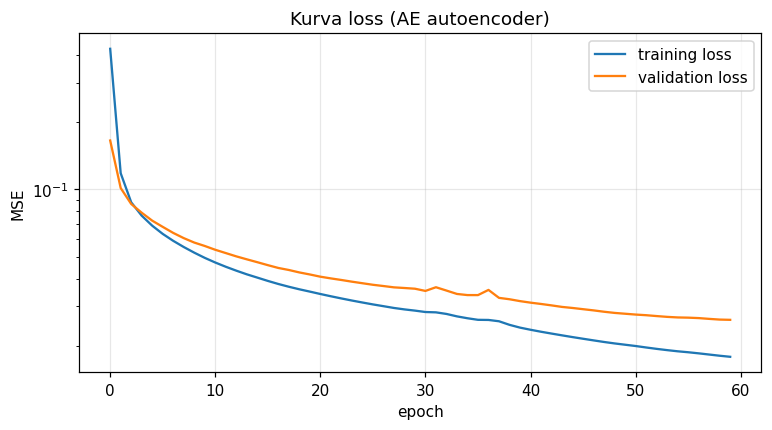

Loss akhir: train=0.0179  val=0.0262


In [13]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='training loss'); plt.plot(history.history['val_loss'], label='validation loss')
plt.yscale('log'); plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend(); plt.title(f'Kurva loss ({model_type.upper()} autoencoder)'); plt.show()
print(f"Loss akhir: train={history.history['loss'][-1]:.4f}  val={history.history['val_loss'][-1]:.4f}")

### 10. Error rekonstruksi (MSE) & penentuan threshold
MSE per window = rata-rata kuadrat selisih input–rekonstruksi di seluruh 24 jam × n_fitur kanal (data ter-scale).
Threshold mengikuti notebook referensi: **rata-rata + 3 × standar deviasi** MSE pada validation set normal.

In [14]:
def window_mse(x, batch_size=256):
    pred = model.predict(x, batch_size=batch_size, verbose=0)
    return np.mean((x - pred) ** 2, axis=(1, 2))

mse_train, mse_val = window_mse(x_train), window_mse(x_val)
mse_test, mse_norm25, mse_anom = window_mse(x_test), window_mse(x_norm25), window_mse(x_anom)

anomaly_threshold = float(mse_val.mean() + 3 * mse_val.std())
print(f'MSE val: mean={mse_val.mean():.4f} std={mse_val.std():.4f}')
print(f'Threshold (mean + 3*std) = {anomaly_threshold:.4f}')
print(f'Pembanding - persentil 99 val = {np.percentile(mse_val, 99):.4f}, persentil 99.5 = {np.percentile(mse_val, 99.5):.4f}')

MSE val: mean=0.0262 std=0.0239
Threshold (mean + 3*std) = 0.0979
Pembanding - persentil 99 val = 0.1123, persentil 99.5 = 0.1234


### 11. Histogram MSE: normal vs anomali (skala log)

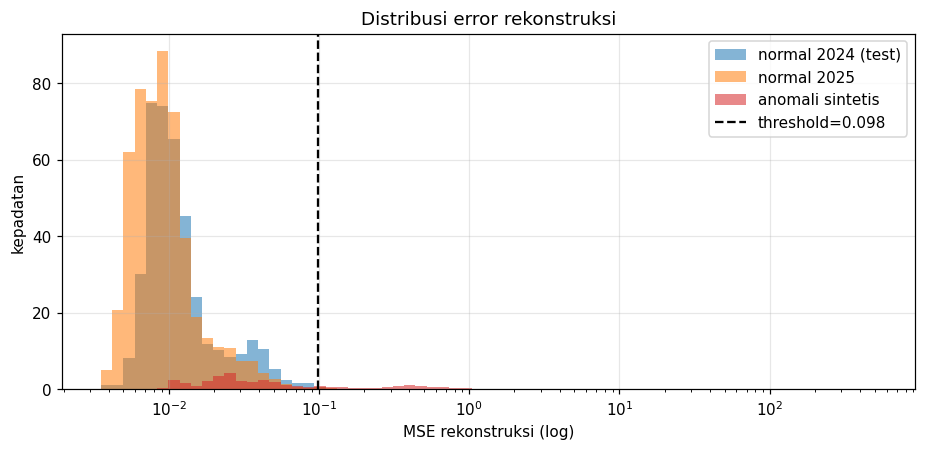

In [15]:
allv = np.concatenate([mse_val, mse_test, mse_norm25, mse_anom])
bins = np.logspace(np.log10(max(allv.min(), 1e-5)), np.log10(allv.max()), 70)
plt.figure(figsize=(10, 4.2))
plt.hist(mse_test,   bins=bins, alpha=.55, density=True, label='normal 2024 (test)')
plt.hist(mse_norm25, bins=bins, alpha=.55, density=True, label='normal 2025')
plt.hist(mse_anom,   bins=bins, alpha=.55, density=True, label='anomali sintetis', color='tab:red')
plt.axvline(anomaly_threshold, color='k', ls='--', label=f'threshold={anomaly_threshold:.3f}')
plt.xscale('log'); plt.xlabel('MSE rekonstruksi (log)'); plt.ylabel('kepadatan'); plt.legend(); plt.title('Distribusi error rekonstruksi'); plt.show()

### 12. Fungsi deteksi & evaluasi (confusion matrix + metrik)

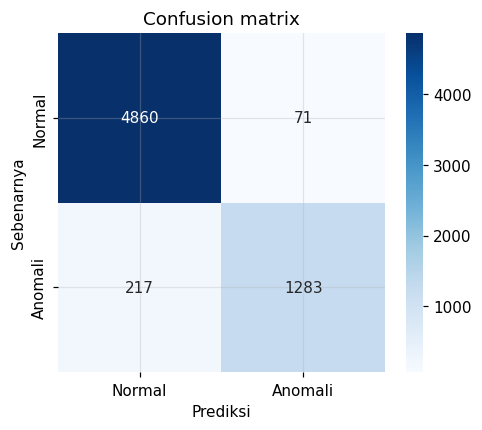

              precision    recall  f1-score   support

      Normal      0.957     0.986     0.971      4931
     Anomali      0.948     0.855     0.899      1500

    accuracy                          0.955      6431
   macro avg      0.952     0.920     0.935      6431
weighted avg      0.955     0.955     0.954      6431

ROC-AUC (independen threshold)          : 0.974
Average precision (independen threshold): 0.951
False-positive rate  2024-test: 0.009 | 2025-normal: 0.016


In [16]:
def detect_anomaly(x, model, threshold, batch_size=256):
    '''Return (is_anomaly[bool per window], mse per window).'''
    pred = model.predict(x, batch_size=batch_size, verbose=0)
    mse = np.mean((x - pred) ** 2, axis=(1, 2))
    return mse > threshold, mse

x_eval = np.concatenate([x_test, x_norm25, x_anom])
y_true = np.concatenate([np.zeros(len(x_test) + len(x_norm25), int), np.ones(len(x_anom), int)])
y_pred, mse_eval = detect_anomaly(x_eval, model, anomaly_threshold)
y_pred = y_pred.astype(int)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomali'], yticklabels=['Normal', 'Anomali'])
plt.xlabel('Prediksi'); plt.ylabel('Sebenarnya'); plt.title('Confusion matrix'); plt.show()

print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomali'], digits=3))
print(f'ROC-AUC (independen threshold)          : {roc_auc_score(y_true, mse_eval):.3f}')
print(f'Average precision (independen threshold): {average_precision_score(y_true, mse_eval):.3f}')
n24 = len(x_test)
print(f'False-positive rate  2024-test: {y_pred[:n24].mean():.3f} | 2025-normal: {y_pred[n24:len(x_test)+len(x_norm25)].mean():.3f}')

Data tidak seimbang (normal ≫ anomali), jadi **accuracy saja menyesatkan** - perhatikan precision/recall/F1 kelas Anomali dan ROC-AUC.

### 13. Recall per skenario & diagnosis error
Mana skenario yang mudah/sulit? Dan di jam & kanal mana model paling "kaget" (peta error per-jam × per-fitur)?

,recall
temp_spike,1.000
co2_extreme,1.000
humidity_saturated_day,0.987
stuck_sensor,0.293
fungal_risk_day,0.997


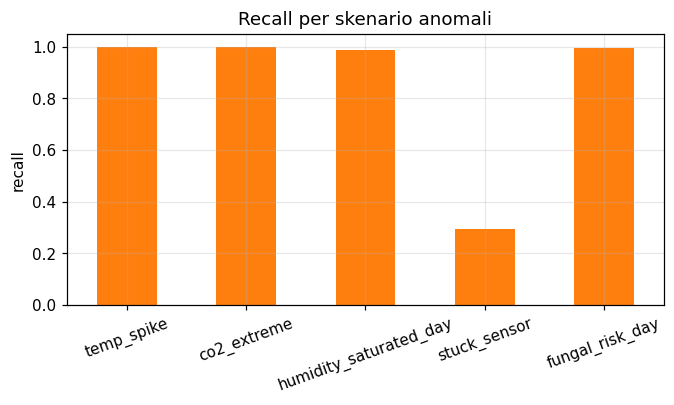

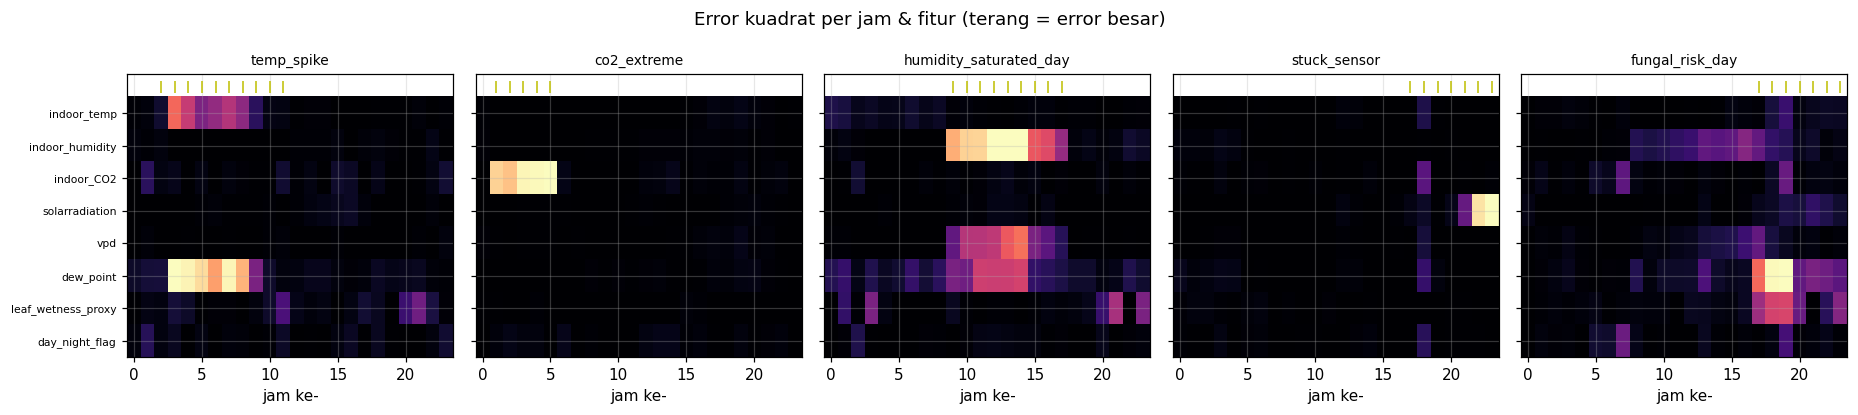

In [17]:
flag_anom = y_pred[-len(x_anom):].astype(bool)
rec = pd.Series({sc: flag_anom[anom_labels == sc].mean() for sc in SCENARIOS})
display(rec.round(3).to_frame('recall'))
plt.figure(figsize=(7, 3.2)); rec.plot.bar(color='tab:orange'); plt.ylim(0, 1.05); plt.ylabel('recall'); plt.xticks(rotation=20); plt.title('Recall per skenario anomali'); plt.show()

# Peta error per (jam x fitur) untuk satu contoh per skenario (panah kuning = jam anomali sebenarnya)
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(17, 3.8), sharey=True)
for ax, sc in zip(axes, SCENARIOS):
    k = int(np.where(anom_labels == sc)[0][0])
    err = (x_anom[k] - model.predict(x_anom[k:k+1], verbose=0)[0]) ** 2          # (T, F)
    ax.imshow(err.T, aspect='auto', cmap='magma', vmin=0, vmax=max(np.percentile(err, 99.5), 1e-6))
    ax.set_title(sc, fontsize=9); ax.set_xlabel('jam ke-'); ax.set_yticks(range(N_FEATURES)); ax.set_yticklabels(FEATURES, fontsize=7)
    hrs = np.where(anom_mask[k])[0]; ax.plot(hrs, np.full(len(hrs), -0.8), 'y|', ms=8, clip_on=False)
plt.suptitle('Error kuadrat per jam & fitur (terang = error besar)'); plt.tight_layout(); plt.show()

### 14. Simpan model, scaler, konfigurasi, dan sampel untuk Notebook 3
- `model.save(... '.h5')` → format Keras (sama seperti referensi).
- `np.savez(...)`: `x_rep` (window normal untuk *representative dataset* kuantisasi int8), `x_val_normal` (kalibrasi ulang threshold model TFLite),
  `x_test_normal`, `x_anomaly` + `anomaly_labels`, serta satu `normal_sample` / `anomaly_sample` (skala asli) untuk uji inference.
- `config.json`: parameter yang harus **identik** saat inference (window, fitur, threshold, day-mask).

In [18]:
def spread(x, n):            # ambil n sampel merata di seluruh array (bukan n pertama)
    return x[np.linspace(0, len(x) - 1, min(n, len(x))).astype(int)]

# balancing: 60 window per skenario
anom_idx = np.concatenate([np.where(anom_labels == sc)[0][:60] for sc in SCENARIOS])
test_normal_mix = np.concatenate([spread(x_test, 150), spread(x_norm25, 150)])

model.save(join(models_path, keras_model_name + '.h5'))
np.savez(join(models_path, sample_file_name + '.npz'),
         x_rep=spread(x_train, 300), x_val_normal=spread(x_val, 500), x_test_normal=test_normal_mix,
         x_anomaly=x_anom[anom_idx], anomaly_labels=anom_labels[anom_idx],
         normal_sample=raw['test'][len(raw['test']) // 2], anomaly_sample=raw_anom[anom_idx[0]],
         anomaly_mask=anom_mask[anom_idx])
config = dict(model_type=model_type, keras_model_name=keras_model_name, window_length_hours=window_length_hours,
              hop_hours=hop_hours, features=FEATURES, n_features=N_FEATURES, anomaly_threshold=anomaly_threshold,
              scaler_file=scaler_name + '.joblib', sample_file=sample_file_name + '.npz',
              day_definition='solarradiation > 1.0 (day_night_flag TIDAK dipakai untuk menentukan siang)',
              architecture='dense autoencoder (Flatten-Dense-Reshape)', hidden_units=list(hidden_units), bottleneck_dim=bottleneck_dim,
              dropped_features=fa_cfg['dropped_missing'] + fa_cfg['dropped_redundant'], impute_policy=fa_cfg['impute_policy'],
              clean_data=fa_cfg['clean_files'], feature_analysis_config='datasets/clean/feature_analysis_config.json')
json.dump(config, open(join(models_path, config_name + '.json'), 'w'), indent=2)
print('Tersimpan di', models_path); print(json.dumps({k: config[k] for k in ['model_type', 'window_length_hours', 'anomaly_threshold']}, indent=1))

Tersimpan di /content/drive/MyDrive/greenhouse-anomaly-edgeai/models
{
 "model_type": "ae",
 "window_length_hours": 24,
 "anomaly_threshold": 0.097878597676754
}


---
## Ringkasan & eksperimen lanjutan
- Data bersih dari Notebook 1 (`datasets/clean/`) dipakai melatih **Autoencoder Dense**; `anomaly_threshold`, daftar fitur, fitur yang dibuang, dan kebijakan imputasi tersimpan di `greenhouse_config.json`.
- Ganti `model_type` ke `'ae'` / `'dae'` / `'vae'` (sel pengaturan) lalu **Run all** untuk membandingkan jenis autoencoder; hasil disimpan dengan nama berbeda. Coba juga `hidden_units`, `bottleneck_dim`, `noise_std` (DAE), dan `vae_beta` / `latent_dim` (VAE).
- Coba `window_length_hours` = 12 / 48 (ubah manual di sel pengaturan, pembagian blok tidak berubah); perhatikan recall skenario singkat (`temp_spike`) vs skenario periodik.
- Threshold `mean + 3σ` sensitif pada distribusi MSE yang miring ke kanan; bandingkan dengan persentil 99 (dicetak di langkah 10) dan pilih sesuai biaya *false alarm* vs *missed detection* di greenhouse.
- Skenario **stuck_sensor** biasanya paling sulit: nilai konstan bisa terlihat wajar bagi model yang hanya melihat MSE rata-rata.
- Lanjut ke **Notebook 3** untuk konversi TFLite + kuantisasi.